# Project Delay Random Forest Models: Keyword Item Percentages and Buckets

This notebook models project delay from the revised project-level correlates file:

`custpaydetails_project_delay_correlates_allcustomers_keyword_pct_buckets_2026-06-08-1329.csv`

The key change in this dataset is that CI description keywords are no longer raw token counts only. For each retained CI keyword, the data includes:

- `CI_KW_<TOKEN>_ITEM_COUNT`: number of distinct contract items whose description contains the keyword.
- `CI_KW_<TOKEN>_ITEM_PCT`: percentage of contract items whose description contains the keyword.
- `CI_KW_<TOKEN>_ITEM_PCT_BUCKET`: bucketed percentage, where 0 means none and larger buckets mean broader item coverage.

The notebook recomputes top correlations from this new data and compares four random-forest scenarios:

- All candidate predictors, excluding bucket fields.
- All candidate predictors, including bucket fields.
- Usable-only candidate predictors, excluding bucket fields.
- Usable-only candidate predictors, including bucket fields.

Both continuous `PERCENTDELAYED` regression and binary delayed/not-delayed classification are evaluated on a deterministic hash train/test split.

In [1]:
import csv, math, hashlib, re
from pathlib import Path
from collections import Counter
import numpy as np
from scipy import stats
from IPython.display import display, HTML, SVG

try:
    import sklearn
    from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
    from sklearn.impute import SimpleImputer
    from sklearn.pipeline import Pipeline
    from sklearn.metrics import (
        mean_absolute_error, mean_squared_error, r2_score,
        accuracy_score, balanced_accuracy_score, precision_score, recall_score,
        f1_score, roc_auc_score
    )
except Exception as e:
    raise RuntimeError('scikit-learn is required for this notebook. Install scikit-learn and rerun.') from e

DATA_FILE = Path('custpaydetails_project_delay_correlates_allcustomers_keyword_pct_buckets_2026-06-08-1329.csv')
OUT_PREFIX = 'project_delay_random_forest_pct_bucket_keywords'
RANDOM_STATE = 20260608
TARGET = 'PERCENTDELAYED'
TARGETS = ['PERCENTDELAYED', 'ACTUALSTARTLAGDAYS', 'ACTUALENDLAGDAYS']

In [2]:
def esc(x):
    return str(x).replace('&','&amp;').replace('<','&lt;').replace('>','&gt;').replace('"','&quot;')

def fmt(x, d=4):
    if x is None: return ''
    try: xf=float(x)
    except Exception: return esc(x)
    if not math.isfinite(xf): return ''
    if abs(xf)>=1000: return f'{xf:,.2f}'
    if abs(xf)>=10: return f'{xf:,.2f}'
    return f'{xf:,.{d}f}'

def table(rows, cols=None, title=None, max_rows=30):
    rows=list(rows)
    if cols is None: cols=list(rows[0].keys()) if rows else []
    h=[]
    if title: h.append('<h3>'+esc(title)+'</h3>')
    h.append('<div style="overflow-x:auto"><table style="border-collapse:collapse;font-size:12px">')
    h.append('<tr>' + ''.join('<th style="border-bottom:1px solid #999;padding:4px 7px;text-align:left;white-space:nowrap">'+esc(c)+'</th>' for c in cols) + '</tr>')
    for r in rows[:max_rows]:
        h.append('<tr>')
        for c in cols:
            v=r.get(c,'')
            align='right' if isinstance(v,(int,float,np.integer,np.floating)) else 'left'
            h.append('<td style="border-bottom:1px solid #ddd;padding:3px 7px;text-align:'+align+';white-space:nowrap">'+fmt(v)+'</td>')
        h.append('</tr>')
    h.append('</table></div>')
    if len(rows)>max_rows:
        h.append('<p style="font-size:12px;color:#555">Showing '+format(max_rows, ',')+' of '+format(len(rows), ',')+' rows.</p>')
    return HTML('\n'.join(h))

def write_csv(path, rows, cols=None):
    rows=list(rows)
    if cols is None: cols=list(rows[0].keys()) if rows else []
    with open(path,'w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f, fieldnames=cols)
        w.writeheader()
        for r in rows: w.writerow({c:r.get(c,'') for c in cols})

def to_float(v):
    s=str(v).strip() if v is not None else ''
    if not s or s.upper() in {'NULL','NAN','NONE'}: return np.nan
    try: return float(s.replace(',',''))
    except Exception: return np.nan

def stable_test_split(customer, project, test_pct=20):
    key=(str(customer)+'|'+str(project)).encode('utf-8')
    return int(hashlib.sha256(key).hexdigest()[:12], 16) % 100 < test_pct

def safe_spearman(x,y):
    x=np.asarray(x,dtype=float); y=np.asarray(y,dtype=float)
    m=np.isfinite(x)&np.isfinite(y); x=x[m]; y=y[m]
    n=len(x)
    if n<5 or len(np.unique(x))<2 or len(np.unique(y))<2: return np.nan, np.nan, n
    try:
        r,p=stats.spearmanr(x,y)
        return float(r), float(p), n
    except Exception:
        return np.nan, np.nan, n

def metric_bar(rows, value_col, label_col='scenario', title='', width=820, height=300, color='#3f6f9f'):
    rows=list(rows)
    vals=[]
    for r in rows:
        try:
            v=float(r[value_col])
            if math.isfinite(v): vals.append(v)
        except Exception: pass
    if not vals: return SVG('<svg/>')
    maxv=max(max(vals), 1e-9)
    minv=min(vals)
    ml,mr,mt,mb=300,35,34,25; w=width-ml-mr; h=height-mt-mb; rh=h/max(len(rows),1)
    parts=[]
    for i,r in enumerate(rows):
        try: v=float(r[value_col])
        except Exception: continue
        y=mt+i*rh+rh*.18
        bw=max(0,v)/maxv*w
        parts.append('<text x="'+str(ml-8)+'" y="'+format(y+rh*.58,'.1f')+'" text-anchor="end" font-size="10">'+esc(r[label_col])+'</text>')
        parts.append('<rect x="'+str(ml)+'" y="'+format(y,'.1f')+'" width="'+format(bw,'.1f')+'" height="'+format(rh*.68,'.1f')+'" fill="'+color+'" opacity="0.85"/>')
        parts.append('<text x="'+format(ml+bw+5,'.1f')+'" y="'+format(y+rh*.58,'.1f')+'" font-size="10">'+fmt(v,3)+'</text>')
    body=''.join(parts)
    return SVG('<svg width="'+str(width)+'" height="'+str(height)+'" xmlns="http://www.w3.org/2000/svg"><style>text{font-family:Arial,sans-serif}</style><text x="'+str(ml)+'" y="22" font-size="15" font-weight="600">'+esc(title)+'</text>'+body+'</svg>')

## Load and Profile the Revised Dataset

In [3]:
with open(DATA_FILE, newline='', encoding='utf-8-sig') as f:
    reader=csv.DictReader(f)
    rows=list(reader)
    cols=reader.fieldnames
raw={c:[r.get(c,'') for r in rows] for c in cols}
num={}
for c in cols:
    if c in {'CUSTOMERNAME','PROJECTNAME'}: continue
    arr=np.array([to_float(v) for v in raw[c]], dtype=float)
    if np.isfinite(arr).sum()>0:
        num[c]=arr
for c in cols:
    if ('_KW_' in c or c.endswith('_ITEM_PCT_BUCKET')) and c in num:
        num[c]=np.where(np.isfinite(num[c]), num[c], 0.0)

bucket_cols=[c for c in cols if c.endswith('_ITEM_PCT_BUCKET')]
ci_count_cols=[c for c in cols if c.startswith('CI_KW_') and c.endswith('_ITEM_COUNT')]
ci_pct_cols=[c for c in cols if c.startswith('CI_KW_') and c.endswith('_ITEM_PCT')]
pm_cols=[c for c in cols if c.startswith('PM_KW_')]
cm_cols=[c for c in cols if c.startswith('CM_KW_')]
split_test=np.array([stable_test_split(r.get('CUSTOMERNAME'), r.get('PROJECTNAME')) for r in rows], dtype=bool)
split_train=~split_test
y=num[TARGET]
y_binary=(y>0).astype(int)

overview=[
 {'metric':'project rows','value':len(rows)}, {'metric':'columns','value':len(cols)}, {'metric':'numeric columns','value':len(num)},
 {'metric':'CI item count keyword cols','value':len(ci_count_cols)}, {'metric':'CI item pct keyword cols','value':len(ci_pct_cols)}, {'metric':'CI item pct bucket cols','value':len(bucket_cols)},
 {'metric':'PM keyword count cols','value':len(pm_cols)}, {'metric':'CM keyword count cols','value':len(cm_cols)},
 {'metric':'train rows','value':int(split_train.sum())}, {'metric':'test rows','value':int(split_test.sum())},
 {'metric':'train delayed share','value':float(y_binary[split_train].mean())}, {'metric':'test delayed share','value':float(y_binary[split_test].mean())},
]
display(table(overview, ['metric','value'], 'Dataset profile'))
display(table([{'CUSTOMERNAME':k,'projects':v,'share_pct':100*v/len(rows)} for k,v in Counter(raw['CUSTOMERNAME']).most_common()], ['CUSTOMERNAME','projects','share_pct'], 'Customer mix'))

metric,value
project rows,"3,331.00"
columns,546.00
numeric columns,538.00
CI item count keyword cols,95.00
CI item pct keyword cols,95.00
CI item pct bucket cols,95.00
PM keyword count cols,84.00
CM keyword count cols,83.00
train rows,"2,683.00"
test rows,648.00


CUSTOMERNAME,projects,share_pct
Lincoln,"1,792.00",53.80
UDOT,"1,327.00",39.84
CCD,135.00,4.0528
Adams,75.00,2.2516
CLV,2.0000,0.0600


## Fresh Correlation Selection from the New Dataset

The model feature sets are selected from this revised data, not from the earlier hardcoded-keyword file. Direct outcome/leakage fields are excluded from selection, but retrospective payment-history predictors remain eligible in the **all** scenarios. The **usable-only** scenarios remove those retrospective fields later.

In [4]:
leakage=set(TARGETS) | {'ACTUALDURATIONDAYS','PAYMENTSPANDAYS','ACTUALSTARTDATE','ACTUALENDDATE','FIRSTPOSTINGDATE','LASTPOSTINGDATE','PLANNEDSTARTTOFIRSTPAYDAYS','PLANNEDENDTOLASTPAYDAYS'}
diag={'TOTALPROJECTCOUNT','IGNOREDINVALIDSCHEDULEPROJECTCOUNT','IGNOREDINVALIDSCHEDULEPROJECTPCT'}

def feature_class(c):
    if c in TARGETS: return 'target'
    if c in leakage: return 'outcome/leakage'
    if c in diag: return 'dataset diagnostic'
    if c.startswith('CI_KW_') and c.endswith('_ITEM_COUNT'): return 'keyword: CI item count'
    if c.startswith('CI_KW_') and c.endswith('_ITEM_PCT'): return 'keyword: CI item pct'
    if c.startswith('CI_KW_') and c.endswith('_ITEM_PCT_BUCKET'): return 'keyword: CI item pct bucket'
    if c.startswith('PM_KW_'): return 'keyword: PM.DESCRIPTION'
    if c.startswith('CM_KW_'): return 'keyword: CM.NAME_DESC'
    return 'numeric predictor'

def is_candidate(c):
    return feature_class(c) not in {'target','outcome/leakage','dataset diagnostic'}

corr_rows=[]
for c,x in num.items():
    if not is_candidate(c): continue
    r,p,n=safe_spearman(x,y)
    corr_rows.append({'feature':c,'class':feature_class(c),'spearman_r':r,'spearman_p':p,'spearman_n':n,'abs_spearman_r':abs(r) if np.isfinite(r) else np.nan,'has_bucket':c.endswith('_ITEM_PCT_BUCKET')})
write_csv(f'{OUT_PREFIX}_all_candidate_spearman_correlations.csv', corr_rows)

def top_pos_neg(allow_buckets):
    pool=[r for r in corr_rows if np.isfinite(r['spearman_r']) and (allow_buckets or not r['has_bucket'])]
    pos=sorted([r for r in pool if r['spearman_r']>0], key=lambda r:-r['spearman_r'])[:20]
    neg=sorted([r for r in pool if r['spearman_r']<0], key=lambda r:r['spearman_r'])[:20]
    selected=[]; seen=set()
    for r in pos+neg:
        if r['feature'] not in seen:
            selected.append(r); seen.add(r['feature'])
    return pos, neg, selected

pos_no, neg_no, selected_no_bucket = top_pos_neg(False)
pos_yes, neg_yes, selected_with_bucket = top_pos_neg(True)
features_no_bucket=[r['feature'] for r in selected_no_bucket]
features_with_bucket=[r['feature'] for r in selected_with_bucket]

selection_rows=[]
for scenario, pos, neg in [('without_buckets',pos_no,neg_no),('with_buckets',pos_yes,neg_yes)]:
    for i,r in enumerate(pos,1): selection_rows.append({'selection_scenario':scenario,'direction':'positive','rank':i,**r})
    for i,r in enumerate(neg,1): selection_rows.append({'selection_scenario':scenario,'direction':'negative','rank':i,**r})
write_csv(f'{OUT_PREFIX}_selected_top_correlates.csv', selection_rows)
display(table(selection_rows, ['selection_scenario','direction','rank','feature','class','spearman_r','spearman_n'], 'Fresh top 20 positive and top 20 negative selections', max_rows=85))

selection_scenario,direction,rank,feature,class,spearman_r,spearman_n
without_buckets,positive,1.0000,PAYDATESPERPLANNEDMONTH,numeric predictor,0.8543,"3,331.00"
without_buckets,positive,2.0000,DOLLARSPERPLANNEDDAY,numeric predictor,0.7953,"3,331.00"
without_buckets,positive,3.0000,DOLLARSPERPLANNEDMONTH,numeric predictor,0.7953,"3,331.00"
without_buckets,positive,4.0000,AVGUNITPRICE,numeric predictor,0.7510,"3,331.00"
without_buckets,positive,5.0000,CI_KW_MOBILIZATION_ITEM_COUNT,keyword: CI item count,0.7473,"3,331.00"
without_buckets,positive,6.0000,ITEMENDSPREADDAYS,numeric predictor,0.7465,"3,331.00"
without_buckets,positive,7.0000,MAXUNITPRICE,numeric predictor,0.7423,"3,331.00"
without_buckets,positive,8.0000,STDDEVUNITPRICE,numeric predictor,0.7406,"3,308.00"
without_buckets,positive,9.0000,MINCONTRACTBURN,numeric predictor,0.7306,"3,331.00"
without_buckets,positive,10.00,DOLLARSPERCONTRACT,numeric predictor,0.7273,"3,331.00"


## Field Viability

`All` models include retrospective payment-history fields selected by correlation. `Usable-only` models retain project/contract/item setup fields and keyword fields but remove payment-history-dependent features.

In [5]:
def viability(feature):
    f=feature.upper()
    if f.startswith('CI_KW_'):
        return ('potentially usable after contract item setup', 'Derived from contract item descriptions and item denominator; usable once item schedule/setup exists.')
    if f.startswith('PM_KW_'):
        return ('likely usable at project setup', 'Derived from project description text.')
    if f.startswith('CM_KW_'):
        return ('likely usable at contract setup', 'Derived from contract name/description text.')
    if f == 'PLANNEDDURATIONDAYS':
        return ('likely usable at project setup', 'Derived from planned start/end dates.')
    if 'DESCRIPTIONTOKENCOUNT' in f or 'TEXTTOKENCOUNT' in f:
        return ('likely usable from setup text', 'Text-count feature from descriptions.')
    if 'UNITPRICE' in f or 'CONTRACTQUANTITY' in f or 'CONTRACTITEMPLANNEDVALUE' in f or 'MISSINGORZEROPLANNEDVALUE' in f:
        return ('potentially usable after contract item setup', 'Requires contract item setup data.')
    retrospective_terms=['PAYDATE','PAYDATES','PAYMENT','POSTING','BURN','DOLLARSPERPLANNED','CONTRACTBURN','ITEMBURN','ITEMENDSPREAD','ITEMSTARTSPREAD','TOTALBURN','ZEROTOTALBURN','NEGATIVE']
    if any(t in f for t in retrospective_terms):
        return ('not usable before payment history', 'Uses realized payment/work-completion behavior or realized burn.')
    return ('needs business review', 'Availability depends on when this field is populated.')

def usable_filter(features):
    return [f for f in features if not viability(f)[0].startswith('not usable')]

features_no_bucket_usable=usable_filter(features_no_bucket)
features_with_bucket_usable=usable_filter(features_with_bucket)
viability_rows=[]
for selection_name, feats in [('without_buckets',features_no_bucket),('with_buckets',features_with_bucket)]:
    for f in feats:
        status,note=viability(f)
        cr=next(r for r in corr_rows if r['feature']==f)
        viability_rows.append({'selection_scenario':selection_name,'feature':f,'class':feature_class(f),'spearman_r':cr['spearman_r'],'viability':status,'comment':note})
write_csv(f'{OUT_PREFIX}_field_viability.csv', viability_rows)
display(table(viability_rows, ['selection_scenario','feature','class','spearman_r','viability','comment'], 'Selected field viability', max_rows=90))
display(table([
 {'scenario':'without_buckets_all','features':len(features_no_bucket)}, {'scenario':'without_buckets_usable','features':len(features_no_bucket_usable)},
 {'scenario':'with_buckets_all','features':len(features_with_bucket)}, {'scenario':'with_buckets_usable','features':len(features_with_bucket_usable)},
], ['scenario','features'], 'Scenario feature counts'))

selection_scenario,feature,class,spearman_r,viability,comment
without_buckets,PAYDATESPERPLANNEDMONTH,numeric predictor,0.8543,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
without_buckets,DOLLARSPERPLANNEDDAY,numeric predictor,0.7953,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
without_buckets,DOLLARSPERPLANNEDMONTH,numeric predictor,0.7953,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
without_buckets,AVGUNITPRICE,numeric predictor,0.7510,potentially usable after contract item setup,Requires contract item setup data.
without_buckets,CI_KW_MOBILIZATION_ITEM_COUNT,keyword: CI item count,0.7473,potentially usable after contract item setup,Derived from contract item descriptions and item denominator; usable once item schedule/setup exists.
without_buckets,ITEMENDSPREADDAYS,numeric predictor,0.7465,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
without_buckets,MAXUNITPRICE,numeric predictor,0.7423,potentially usable after contract item setup,Requires contract item setup data.
without_buckets,STDDEVUNITPRICE,numeric predictor,0.7406,potentially usable after contract item setup,Requires contract item setup data.
without_buckets,MINCONTRACTBURN,numeric predictor,0.7306,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
without_buckets,DOLLARSPERCONTRACT,numeric predictor,0.7273,needs business review,Availability depends on when this field is populated.


scenario,features
without_buckets_all,40.00
without_buckets_usable,23.00
with_buckets_all,40.00
with_buckets_usable,24.00


## Random Forest Training and Evaluation

Each scenario trains a random forest regressor for `PERCENTDELAYED` and a random forest classifier for `PERCENTDELAYED > 0`.

scenario,features,train_rows,test_rows,mae,rmse,r2,bias_pred_minus_actual,baseline_mae,baseline_rmse,baseline_r2
without_buckets_all,40.00,"2,683.00",648.00,29.12,104.46,0.8385,3.7902,164.62,269.33,-0.0737
with_buckets_all,40.00,"2,683.00",648.00,29.05,104.80,0.8374,3.7686,164.62,269.33,-0.0737
without_buckets_usable,23.00,"2,683.00",648.00,98.19,189.30,0.4696,4.2184,164.62,269.33,-0.0737
with_buckets_usable,24.00,"2,683.00",648.00,98.44,189.98,0.4658,4.7559,164.62,269.33,-0.0737


scenario,features,train_rows,test_rows,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,baseline_accuracy,baseline_balanced_accuracy
without_buckets_all,40.00,"2,683.00",648.00,0.9460,0.9453,0.9459,0.9540,0.9499,0.9907,0.5370,0.5000
with_buckets_all,40.00,"2,683.00",648.00,0.9429,0.9422,0.9430,0.9511,0.9471,0.9906,0.5370,0.5000
without_buckets_usable,23.00,"2,683.00",648.00,0.9151,0.9139,0.9127,0.9310,0.9218,0.9700,0.5370,0.5000
with_buckets_usable,24.00,"2,683.00",648.00,0.9105,0.9098,0.9143,0.9195,0.9169,0.9704,0.5370,0.5000


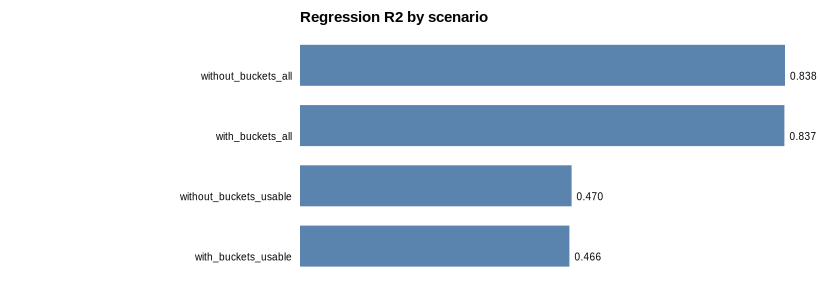

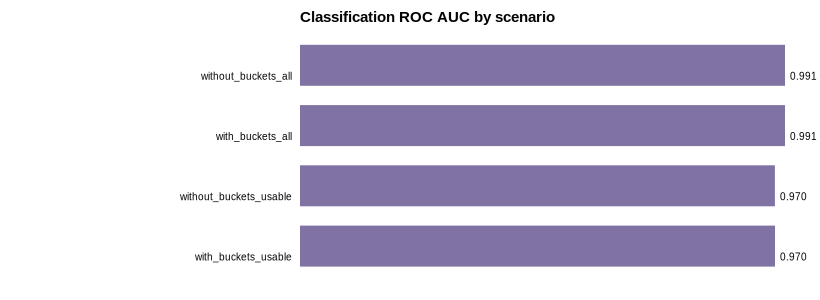

In [6]:
def make_X(features):
    return np.column_stack([num[f] for f in features]).astype(float)

def baseline_reg(ytr,yte):
    pred=np.full_like(yte, np.nanmedian(ytr), dtype=float)
    return float(mean_absolute_error(yte,pred)), float(math.sqrt(mean_squared_error(yte,pred))), float(r2_score(yte,pred))

def baseline_cls(ytr,yte):
    maj=int(np.mean(ytr)>=0.5)
    pred=np.full_like(yte, maj, dtype=int)
    return float(accuracy_score(yte,pred)), float(balanced_accuracy_score(yte,pred))

def run_scenario(name, features):
    X=make_X(features)
    mask=np.isfinite(y)
    train=split_train & mask; test=split_test & mask
    Xtr,Xte=X[train],X[test]
    ytr,yte=y[train],y[test]
    ybtr,ybte=y_binary[train],y_binary[test]
    reg=Pipeline([('imputer',SimpleImputer(strategy='median')),('model',RandomForestRegressor(n_estimators=500,min_samples_leaf=5,random_state=RANDOM_STATE,n_jobs=-1))])
    clf=Pipeline([('imputer',SimpleImputer(strategy='median')),('model',RandomForestClassifier(n_estimators=500,min_samples_leaf=5,class_weight='balanced_subsample',random_state=RANDOM_STATE,n_jobs=-1))])
    reg.fit(Xtr,ytr); clf.fit(Xtr,ybtr)
    pr=reg.predict(Xte); pc=clf.predict(Xte); pp=clf.predict_proba(Xte)[:,1]
    bmae,brmse,br2=baseline_reg(ytr,yte)
    bacc,bbal=baseline_cls(ybtr,ybte)
    reg_m={'scenario':name,'features':len(features),'train_rows':int(train.sum()),'test_rows':int(test.sum()),'mae':float(mean_absolute_error(yte,pr)),'rmse':float(math.sqrt(mean_squared_error(yte,pr))),'r2':float(r2_score(yte,pr)),'bias_pred_minus_actual':float(np.mean(pr-yte)),'baseline_mae':bmae,'baseline_rmse':brmse,'baseline_r2':br2}
    cls_m={'scenario':name,'features':len(features),'train_rows':int(train.sum()),'test_rows':int(test.sum()),'accuracy':float(accuracy_score(ybte,pc)),'balanced_accuracy':float(balanced_accuracy_score(ybte,pc)),'precision':float(precision_score(ybte,pc,zero_division=0)),'recall':float(recall_score(ybte,pc,zero_division=0)),'f1':float(f1_score(ybte,pc,zero_division=0)),'roc_auc':float(roc_auc_score(ybte,pp)) if len(np.unique(ybte))>1 else np.nan,'baseline_accuracy':bacc,'baseline_balanced_accuracy':bbal}
    imps=[]
    for f,ri,ci in zip(features, reg.named_steps['model'].feature_importances_, clf.named_steps['model'].feature_importances_):
        status,note=viability(f)
        imps.append({'scenario':name,'feature':f,'class':feature_class(f),'regression_importance':float(ri),'classification_importance':float(ci),'viability':status,'comment':note})
    preds=[]
    for idx,a,pred,actual_bin,pred_bin,prob in zip(np.where(test)[0],yte,pr,ybte,pc,pp):
        preds.append({'scenario':name,'CUSTOMERNAME':raw['CUSTOMERNAME'][idx],'PROJECTNAME':raw['PROJECTNAME'][idx],'actual_percent_delayed':float(a),'predicted_percent_delayed':float(pred),'absolute_error':float(abs(pred-a)),'actual_delayed':int(actual_bin),'predicted_delayed':int(pred_bin),'predicted_delay_probability':float(prob)})
    return reg_m, cls_m, imps, preds

scenarios=[
 ('without_buckets_all', features_no_bucket),
 ('with_buckets_all', features_with_bucket),
 ('without_buckets_usable', features_no_bucket_usable),
 ('with_buckets_usable', features_with_bucket_usable),
]
reg_metrics=[]; cls_metrics=[]; importances=[]; predictions=[]
for name, feats in scenarios:
    rm,cm,im,pr=run_scenario(name, feats)
    reg_metrics.append(rm); cls_metrics.append(cm); importances.extend(im); predictions.extend(pr)
write_csv(f'{OUT_PREFIX}_regression_metrics.csv', reg_metrics)
write_csv(f'{OUT_PREFIX}_classification_metrics.csv', cls_metrics)
write_csv(f'{OUT_PREFIX}_feature_importances.csv', importances)
write_csv(f'{OUT_PREFIX}_test_predictions.csv', predictions)
display(table(reg_metrics, ['scenario','features','train_rows','test_rows','mae','rmse','r2','bias_pred_minus_actual','baseline_mae','baseline_rmse','baseline_r2'], 'Regression performance'))
display(table(cls_metrics, ['scenario','features','train_rows','test_rows','accuracy','balanced_accuracy','precision','recall','f1','roc_auc','baseline_accuracy','baseline_balanced_accuracy'], 'Binary classification performance'))
display(metric_bar(reg_metrics, 'r2', title='Regression R2 by scenario'))
display(metric_bar(cls_metrics, 'roc_auc', title='Classification ROC AUC by scenario', color='#6b5b95'))

## Feature Importances

In [7]:
for name,_ in scenarios:
    rs=sorted([r for r in importances if r['scenario']==name], key=lambda r:-r['regression_importance'])[:25]
    display(table(rs, ['feature','class','regression_importance','classification_importance','viability','comment'], 'Top regression importances: '+name, max_rows=25))

feature,class,regression_importance,classification_importance,viability,comment
PLANNEDDURATIONDAYS,numeric predictor,0.2842,0.0241,likely usable at project setup,Derived from planned start/end dates.
ITEMSTARTSPREADDAYS,numeric predictor,0.2032,0.0246,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
PAYDATESPERPLANNEDMONTH,numeric predictor,0.1470,0.0378,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
ITEMENDSPREADDAYS,numeric predictor,0.1150,0.0261,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
DOLLARSPERPLANNEDMONTH,numeric predictor,0.1093,0.1317,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
DOLLARSPERPLANNEDDAY,numeric predictor,0.0996,0.1164,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
CI_KW_MOBILIZATION_ITEM_COUNT,keyword: CI item count,0.0076,0.0066,potentially usable after contract item setup,Derived from contract item descriptions and item denominator; usable once item schedule/setup exists.
STDDEVUNITPRICE,numeric predictor,0.0070,0.0448,potentially usable after contract item setup,Requires contract item setup data.
STDDEVCONTRACTITEMPLANNEDVALUE,numeric predictor,0.0045,0.0544,potentially usable after contract item setup,Requires contract item setup data.
SHARESINGLEPAYDATEITEMS,numeric predictor,0.0043,0.0034,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.


feature,class,regression_importance,classification_importance,viability,comment
PLANNEDDURATIONDAYS,numeric predictor,0.2848,0.0248,likely usable at project setup,Derived from planned start/end dates.
ITEMSTARTSPREADDAYS,numeric predictor,0.2037,0.0266,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
PAYDATESPERPLANNEDMONTH,numeric predictor,0.1465,0.0342,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
ITEMENDSPREADDAYS,numeric predictor,0.1163,0.0252,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
DOLLARSPERPLANNEDMONTH,numeric predictor,0.1065,0.1294,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
DOLLARSPERPLANNEDDAY,numeric predictor,0.1016,0.1192,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.
STDDEVUNITPRICE,numeric predictor,0.0077,0.0709,potentially usable after contract item setup,Requires contract item setup data.
CI_KW_MOBILIZATION_ITEM_PCT_BUCKET,keyword: CI item pct bucket,0.0049,0.0179,potentially usable after contract item setup,Derived from contract item descriptions and item denominator; usable once item schedule/setup exists.
STDDEVCONTRACTITEMPLANNEDVALUE,numeric predictor,0.0044,0.0613,potentially usable after contract item setup,Requires contract item setup data.
SHARESINGLEPAYDATEITEMS,numeric predictor,0.0043,0.0035,not usable before payment history,Uses realized payment/work-completion behavior or realized burn.


feature,class,regression_importance,classification_importance,viability,comment
PLANNEDDURATIONDAYS,numeric predictor,0.4237,0.0478,likely usable at project setup,Derived from planned start/end dates.
DOLLARSPERCONTRACT,numeric predictor,0.2266,0.0976,needs business review,Availability depends on when this field is populated.
MAXUNITPRICE,numeric predictor,0.1454,0.1569,potentially usable after contract item setup,Requires contract item setup data.
AVGUNITPRICE,numeric predictor,0.0645,0.1432,potentially usable after contract item setup,Requires contract item setup data.
STDDEVCONTRACTITEMPLANNEDVALUE,numeric predictor,0.0461,0.1258,potentially usable after contract item setup,Requires contract item setup data.
STDDEVUNITPRICE,numeric predictor,0.0303,0.1204,potentially usable after contract item setup,Requires contract item setup data.
CMTEXTTOKENCOUNT,numeric predictor,0.0146,0.0146,likely usable from setup text,Text-count feature from descriptions.
CMTEXTDISTINCTTOKENCOUNT,numeric predictor,0.0118,0.0053,needs business review,Availability depends on when this field is populated.
CI_KW_MOBILIZATION_ITEM_COUNT,keyword: CI item count,0.0113,0.0698,potentially usable after contract item setup,Derived from contract item descriptions and item denominator; usable once item schedule/setup exists.
PMDESCRIPTIONTOKENCOUNT,numeric predictor,0.0102,0.0298,likely usable from setup text,Text-count feature from descriptions.


feature,class,regression_importance,classification_importance,viability,comment
PLANNEDDURATIONDAYS,numeric predictor,0.4214,0.0433,likely usable at project setup,Derived from planned start/end dates.
DOLLARSPERCONTRACT,numeric predictor,0.2202,0.1128,needs business review,Availability depends on when this field is populated.
MAXUNITPRICE,numeric predictor,0.1420,0.1600,potentially usable after contract item setup,Requires contract item setup data.
AVGUNITPRICE,numeric predictor,0.0619,0.1453,potentially usable after contract item setup,Requires contract item setup data.
STDDEVCONTRACTITEMPLANNEDVALUE,numeric predictor,0.0441,0.1024,potentially usable after contract item setup,Requires contract item setup data.
STDDEVUNITPRICE,numeric predictor,0.0291,0.0946,potentially usable after contract item setup,Requires contract item setup data.
CI_KW_MOBILIZATION_ITEM_PCT_BUCKET,keyword: CI item pct bucket,0.0234,0.0676,potentially usable after contract item setup,Derived from contract item descriptions and item denominator; usable once item schedule/setup exists.
CMTEXTTOKENCOUNT,numeric predictor,0.0144,0.0136,likely usable from setup text,Text-count feature from descriptions.
CMTEXTDISTINCTTOKENCOUNT,numeric predictor,0.0125,0.0057,needs business review,Availability depends on when this field is populated.
PMDESCRIPTIONDISTINCTTOKENCOUNT,numeric predictor,0.0090,0.0297,needs business review,Availability depends on when this field is populated.


## Bucket Added Value Summary

This section directly compares the no-bucket and with-bucket results for all-field and usable-only settings.

In [8]:
def by_scenario(rows): return {r['scenario']:r for r in rows}
rg=by_scenario(reg_metrics); cl=by_scenario(cls_metrics)
comparisons=[]
for prefix in ['all','usable']:
    no='without_buckets_'+prefix
    yes='with_buckets_'+prefix
    comparisons.append({
        'setting':prefix,
        'no_bucket_features':rg[no]['features'],
        'with_bucket_features':rg[yes]['features'],
        'r2_no_bucket':rg[no]['r2'],
        'r2_with_bucket':rg[yes]['r2'],
        'r2_delta':rg[yes]['r2']-rg[no]['r2'],
        'mae_no_bucket':rg[no]['mae'],
        'mae_with_bucket':rg[yes]['mae'],
        'mae_delta':rg[yes]['mae']-rg[no]['mae'],
        'auc_no_bucket':cl[no]['roc_auc'],
        'auc_with_bucket':cl[yes]['roc_auc'],
        'auc_delta':cl[yes]['roc_auc']-cl[no]['roc_auc'],
    })
write_csv(f'{OUT_PREFIX}_bucket_added_value.csv', comparisons)
display(table(comparisons, ['setting','no_bucket_features','with_bucket_features','r2_no_bucket','r2_with_bucket','r2_delta','mae_no_bucket','mae_with_bucket','mae_delta','auc_no_bucket','auc_with_bucket','auc_delta'], 'Added value of bucket features'))

summary=[]
summary.append('The revised pct/bucket dataset contains '+format(len(rows),',')+' projects and '+format(len(cols),',')+' columns.')
for c in comparisons:
    summary.append(c['setting']+': adding bucket-eligible selection changed regression R2 by '+fmt(c['r2_delta'],3)+', MAE by '+fmt(c['mae_delta'],2)+', and classification AUC by '+fmt(c['auc_delta'],3)+'.')
summary.append('Interpretation: positive R2/AUC deltas and negative MAE deltas indicate that bucket features or bucket-influenced feature selection added value.')
summary.append('The usable-only scenarios are the better approximation of a deployable early-risk model; the all-field scenarios can still include retrospective payment-history signals.')
display(HTML('<ul>'+''.join('<li>'+esc(s)+'</li>' for s in summary)+'</ul>'))
with open(f'{OUT_PREFIX}_summary.md','w',encoding='utf-8') as f:
    f.write('# Project Delay Random Forest Pct/Bucket Keyword Summary\n\n')
    for s in summary: f.write('- '+s+'\n')

setting,no_bucket_features,with_bucket_features,r2_no_bucket,r2_with_bucket,r2_delta,mae_no_bucket,mae_with_bucket,mae_delta,auc_no_bucket,auc_with_bucket,auc_delta
all,40.00,40.00,0.8385,0.8374,-0.0010,29.12,29.05,-0.0702,0.9907,0.9906,-0.0001
usable,23.00,24.00,0.4696,0.4658,-0.0038,98.19,98.44,0.2477,0.9700,0.9704,0.0003
